# Load and run models

In [1]:
%load_ext autoreload

In [2]:
%autoreload 2

In [3]:
cd ..

/Users/alain/Desktop/master-thesis/guiding-generative-probabilistic-weather-models


In [4]:
from geoarches.lightning_modules import load_module

## Load ArchesWeather

In [4]:
# load_module will look in modelstore/
model, config = load_module("archesweather-m-seed0")

Restored from modelstore/archesweather-m-seed0/checkpoints/checkpoint.ckpt


In [5]:
# we can also load the 4-members deterministic ensemble ArchesWeather-Mx4 like so:

model, config = load_module(
    "archesweather-m-seed0",
    avg_with_modules=[
        "archesweather-m-seed1",
        "archesweather-m-skip-seed0",
        "archesweather-m-skip-seed1",
    ],
)

Restored from modelstore/archesweather-m-seed1/checkpoints/checkpoint.ckpt
Restored from modelstore/archesweather-m-skip-seed0/checkpoints/checkpoint.ckpt
Restored from modelstore/archesweather-m-skip-seed1/checkpoints/checkpoint.ckpt
Restored from modelstore/archesweather-m-seed0/checkpoints/checkpoint.ckpt


## Era5 Dataloader

In [6]:
# load sample from dataloader
from geoarches.dataloaders.era5 import Era5Forecast

ds = Era5Forecast(
    path="data/era5_240/full",  # default path
    load_prev=True,  # whether to load previous state
    norm_scheme="pangu",  # default normalization scheme
    domain="test",  # domain to consider. domain = 'test' loads the 2020 period
    lead_time_hours=6
)

4it [00:00, 11.86it/s]

start time 2019-12-31T18:00:00


In [10]:
# The dataset returns a dict of TensorDict:
print("keys in a sample:", ds[0].keys())
# a state contains level and surface variables in a TensorDict, which is a specialized structure for dict of tensors
print("sample state", ds[0]["state"])

keys in a sample: dict_keys(['timestamp', 'state', 'lead_time_hours', 'next_state', 'prev_state'])
sample state TensorDict(
    fields={
        level: Tensor(shape=torch.Size([6, 13, 121, 240]), device=cpu, dtype=torch.float32, is_shared=False),
        surface: Tensor(shape=torch.Size([4, 1, 121, 240]), device=cpu, dtype=torch.float32, is_shared=False)},
    batch_size=torch.Size([]),
    device=None,
    is_shared=False)


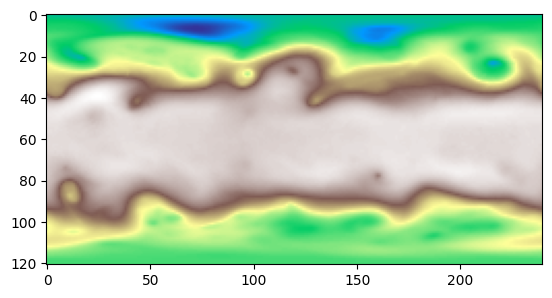

In [11]:
# we can visualize a sample, e.g. Z500, with the following

import matplotlib.pyplot as plt

plt.imshow(ds[0]["state"]["level"][0, 7], cmap="terrain")

## Run ArchesWeather

In [11]:
# now we can run inference with the deterministic model ArchesWeather:
import torch

torch.set_grad_enabled(False)

device = "mps"

model = model.to(device)

batch = {k: v[None].to(device) for k, v in ds[4].items()}

pred = model(batch).cpu()

times in ForecastModuleWithCond: DatetimeIndex(['2020-01-02 06:00:00'], dtype='datetime64[s]', freq=None), Index([1], dtype='int32'), Index([6], dtype='int32')


In [14]:
# optionally, we can denormalize the prediction to go back to real physical values
pred = ds.denormalize(pred)

24h Z500 prediction


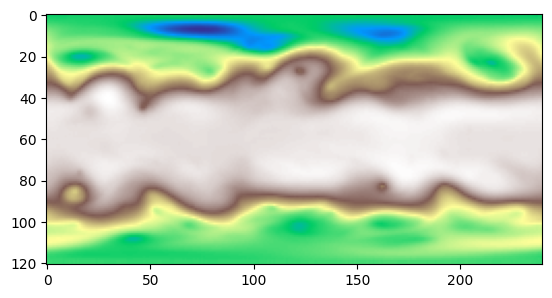

24h ground truth


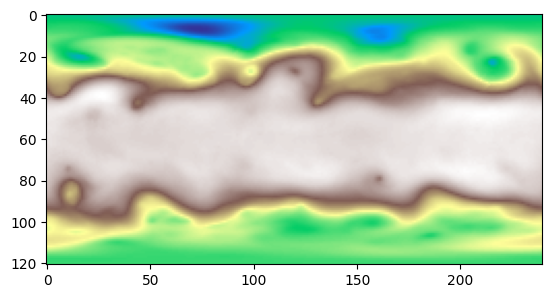

In [15]:
# we can visualize predictions, compared to ground truth

print("24h Z500 prediction")
plt.imshow(pred["level"][0, 0, 7], cmap="terrain")
plt.show()

print("24h ground truth")
plt.imshow(ds[0]["next_state"]["level"][0, 7], cmap="terrain")
plt.show()

In [16]:
# we can also do multistep rollouts with the deterministic model:
pred_multistep = model.forward_multistep(batch, iters=10)  # this does a 10-day rollout
# the rollout dimension is the second dimension in the predicted tensors
pred_multistep

TensorDict(
    fields={
        level: Tensor(shape=torch.Size([1, 10, 6, 13, 121, 240]), device=mps:0, dtype=torch.float32, is_shared=False),
        surface: Tensor(shape=torch.Size([1, 10, 4, 1, 121, 240]), device=mps:0, dtype=torch.float32, is_shared=False)},
    batch_size=torch.Size([1, 10]),
    device=mps:0,
    is_shared=False)

## Loading and running ArchesWeatherGen

In [5]:
# loading ArchesWeatherFlow
device = "mps"

# load_module will look in modelstore/
gen_model, gen_config = load_module(
    "archesweathergen",
    module_target="geoarches.lightning_modules.diffusion.DiffusionModule",
)

gen_model = gen_model.to(device)

initialized DiffusionModule
Restored from modelstore/archesweather-m-seed0/checkpoints/checkpoint.ckpt
Restored from modelstore/archesweather-m-seed1/checkpoints/checkpoint.ckpt
Restored from modelstore/archesweather-m-skip-seed0/checkpoints/checkpoint.ckpt
Restored from modelstore/archesweather-m-skip-seed1/checkpoints/checkpoint.ckpt
Restored from modelstore/archesweathergen/checkpoints/checkpoint.ckpt


In [10]:
# run model on a sample
seed = 0
num_steps = 25  # if not provided to model.sample, model will use the default value (25)
scale_input_noise = 1.05

batch = {k: v[None].to(device) for k, v in ds[2].items()}


sample = gen_model.sample(
    batch, seed=seed, num_steps=num_steps, scale_input_noise=scale_input_noise
).cpu()

seed: 0


  0%|          | 0/25 [00:00<?, ?it/s]

timestamp: DatetimeIndex(['1970-01-01 00:00:00.646266880'], dtype='datetime64[ns]', freq=None), month: Index([1], dtype='int32'), hour: Index([0], dtype='int32')


  0%|          | 0/25 [00:08<?, ?it/s]


KeyboardInterrupt: 

In [19]:
# run a model auto-regressively

rollout_iterations = 10
n_members = 1

sample_multistep = [
    gen_model.sample_rollout(
        batch,
        batch_nb=0,  # should be different for each input
        member=i,
        iterations=rollout_iterations,
    )
    for i in range(n_members)
]

  0%|          | 0/10 [00:00<?, ?it/s]

seed_i: 0
seed: 0


  0%|          | 0/10 [00:16<?, ?it/s]


KeyboardInterrupt: 